=== LOAD DATA ===
   household_id device_category device_brand device_model maintenance_status  \
0          8270            HVAC    Whirlpool           M2               Good   
1          1860            HVAC           LG           M2           Critical   
2          6390    Refrigerator    Whirlpool           M1               Good   
3          6191           Dryer    Whirlpool           M3            Average   
4          6734           Dryer           LG           M2               Good   

  installation_region  runtime_hours  device_power_kw  motor_speed_rpm  \
0               North      21.957749         1.673346      2278.663274   
1               North       1.666840         4.340784      2295.481003   
2                East       3.256854         5.166788      1415.218144   
3               South      23.515489         3.740279       549.159135   
4                West      19.294287         0.532979      2765.581547   

   efficiency_ratio  energy_draw_kwh  heat_output  cooli

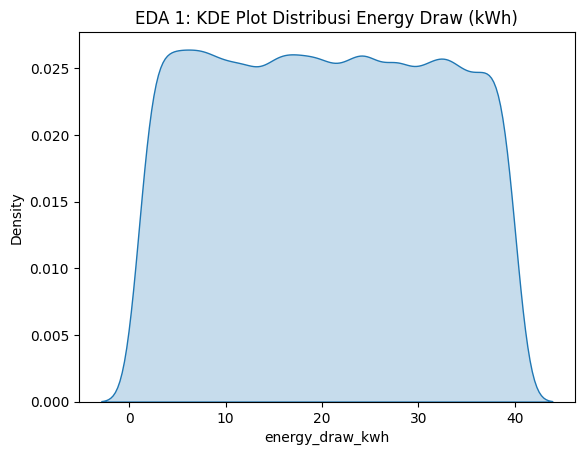


=== EDA 2: Distribusi Device Category ===


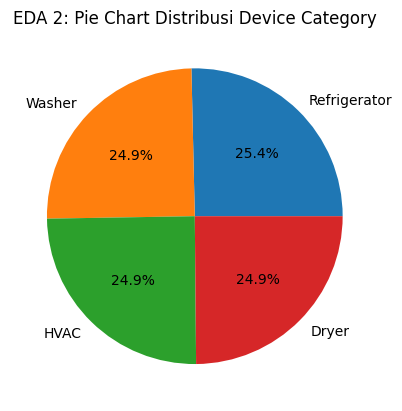


=== EDA 3: Maintenance vs Energy ===


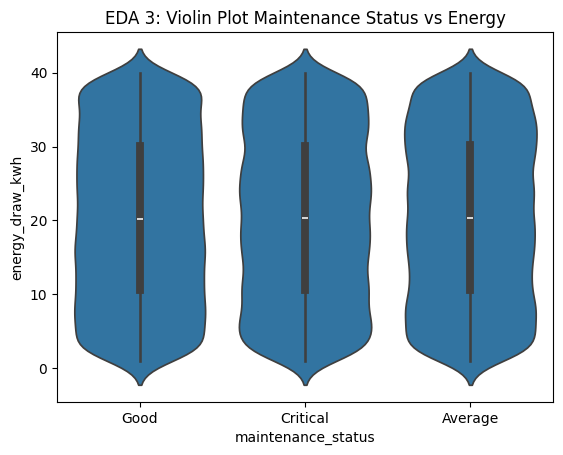


=== FILTER DATA: WASHER ===
Jumlah data Washer: 12451
    household_id device_category device_brand device_model maintenance_status  \
7           5426          Washer    Whirlpool           M1           Critical   
8           6578          Washer    Whirlpool           M1               Good   
9           9322          Washer      Samsung           M2            Average   
11          1769          Washer           LG           M2           Critical   
12          7949          Washer    Whirlpool           M1           Critical   

   installation_region  runtime_hours  device_power_kw  motor_speed_rpm  \
7                 West      21.862292         7.526943      2737.907422   
8                South      20.283928         1.473867      1323.904355   
9                 West      19.233457         4.292660      1137.503945   
11               North       5.952299         4.576736      1115.917888   
12                East       3.871491         3.110882      1672.896427   

    eff

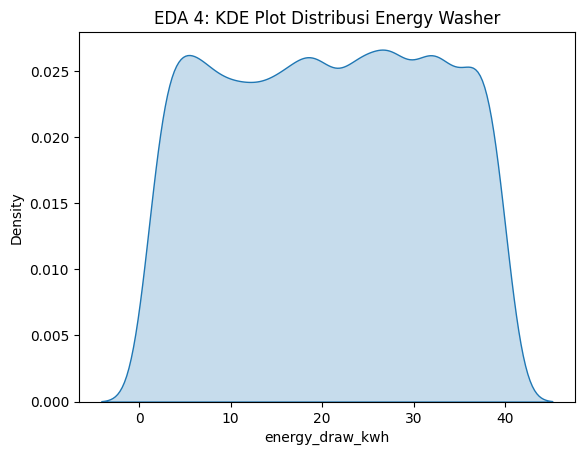


=== EDA 5: Power vs Energy Washer ===


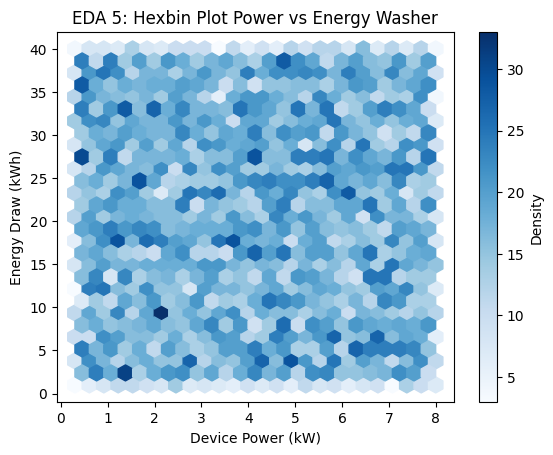


=== EDA 6: Maintenance vs Energy Washer ===


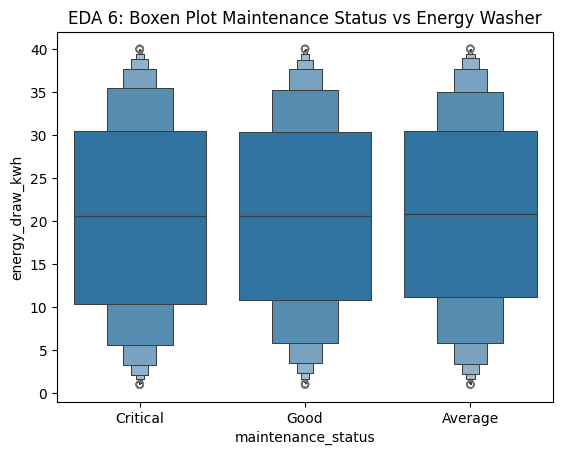

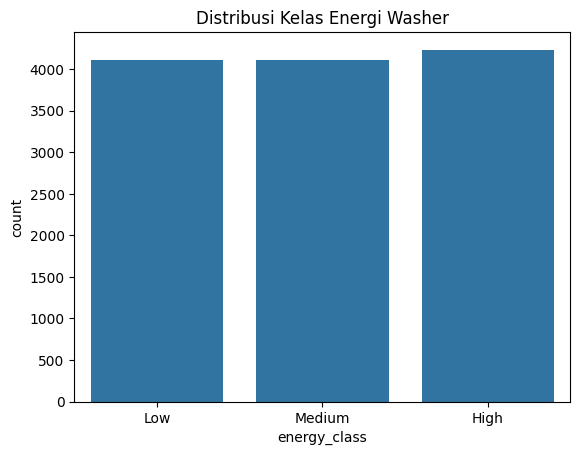


=== MODELING + GRID SEARCH ===
Best Params: {'max_depth': 5, 'n_estimators': 100}

=== EVALUASI MODEL ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       814
           1       1.00      1.00      1.00       877
           2       1.00      1.00      1.00       800

    accuracy                           1.00      2491
   macro avg       1.00      1.00      1.00      2491
weighted avg       1.00      1.00      1.00      2491



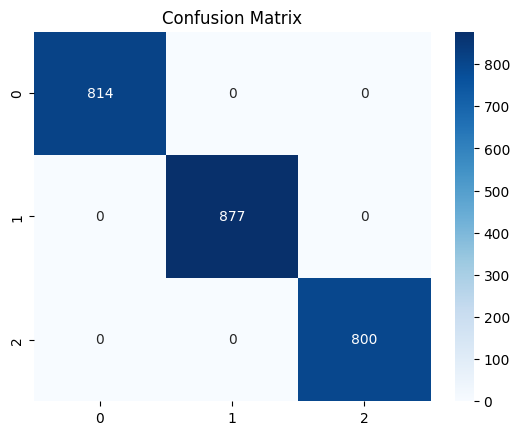


=== HASIL PREDIKSI SAMPLE ===
Brand: LG -> Prediksi: Medium
Brand: Samsung -> Prediksi: High
Brand: Whirlpool -> Prediksi: Medium
Brand: Whirlpool -> Prediksi: Medium
Brand: LG -> Prediksi: High


In [1]:
# ===============================
# 1. IMPORT LIBRARY
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ===============================
# 2. LOAD DATA
# ===============================
print("=== LOAD DATA ===")
df = pd.read_csv('device_metrics_stream_v2.csv')
print(df.head())
print(df.info())

# ===============================
# 3. EDA GLOBAL
# ===============================

# EDA 1: Univariate Analysis (KDE Plot)
print("\n=== EDA 1: Distribusi Energy Draw ===")
plt.figure()
sns.kdeplot(df['energy_draw_kwh'], fill=True)
plt.title('EDA 1: KDE Plot Distribusi Energy Draw (kWh)')
plt.show()

# EDA 2: Categorical Distribution (Pie Chart)
print("\n=== EDA 2: Distribusi Device Category ===")
plt.figure()
df['device_category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('EDA 2: Pie Chart Distribusi Device Category')
plt.ylabel('')
plt.show()

# EDA 3: Bivariate Analysis (Violin Plot)
print("\n=== EDA 3: Maintenance vs Energy ===")
plt.figure()
sns.violinplot(x='maintenance_status', y='energy_draw_kwh', data=df)
plt.title('EDA 3: Violin Plot Maintenance Status vs Energy')
plt.show()

# ===============================
# 4. FILTER WASHER
# ===============================
# Data Filtering (Subset Selection)
print("\n=== FILTER DATA: WASHER ===")
washer_df = df[df['device_category'] == 'Washer']
print("Jumlah data Washer:", len(washer_df))
print(washer_df.head())

# ===============================
# 5. EDA KHUSUS WASHER
# ===============================

# EDA 4: Univariate Analysis (KDE Plot)
print("\n=== EDA 4: Distribusi Energy Washer ===")
plt.figure()
sns.kdeplot(washer_df['energy_draw_kwh'], fill=True)
plt.title('EDA 4: KDE Plot Distribusi Energy Washer')
plt.show()

# EDA 5: Bivariate Analysis (Regression Plot)
print("\n=== EDA 5: Power vs Energy Washer ===")
plt.figure()
plt.hexbin(washer_df['device_power_kw'], washer_df['energy_draw_kwh'], gridsize=25, cmap='Blues')
plt.colorbar(label='Density')
plt.xlabel('Device Power (kW)')
plt.ylabel('Energy Draw (kWh)')
plt.title('EDA 5: Hexbin Plot Power vs Energy Washer')
plt.show()

# EDA 6: Bivariate Analysis (Bar Plot - Mean)
print("\n=== EDA 6: Maintenance vs Energy Washer ===")
plt.figure()
sns.boxenplot(x='maintenance_status', y='energy_draw_kwh', data=washer_df)
plt.title('EDA 6: Boxen Plot Maintenance Status vs Energy Washer')
plt.show()

# ===============================
# 6. CREATE TARGET
# ===============================
# Label Engineering (Discretization / Binning)

def classify_energy(val):
    if val < washer_df['energy_draw_kwh'].quantile(0.33):
        return 'Low'
    elif val < washer_df['energy_draw_kwh'].quantile(0.66):
        return 'Medium'
    else:
        return 'High'

washer_df['energy_class'] = washer_df['energy_draw_kwh'].apply(classify_energy)

plt.figure()
sns.countplot(x='energy_class', data=washer_df)
plt.title('Distribusi Kelas Energi Washer')
plt.show()

# ===============================
# 7. PREPROCESSING
# ===============================

# Simpan brand untuk output
brand_data = washer_df['device_brand']

# Preprocessing 1: Feature Selection
washer_df = washer_df.drop(columns=['household_id', 'device_category'], errors='ignore')

# Preprocessing 2: Encoding (Label Encoding)
cat_cols = ['device_brand', 'device_model',
            'maintenance_status', 'installation_region']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    washer_df[col] = le.fit_transform(washer_df[col].astype(str))
    le_dict[col] = le

# Preprocessing 3: Feature-Target Split
X = washer_df.drop('energy_class', axis=1)
y = washer_df['energy_class']

# Preprocessing 4: Select Numerical Features
X = X.select_dtypes(include=np.number)

# Preprocessing 5: Missing Value Handling (Imputation)
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Preprocessing 6: Scaling (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preprocessing 7: Encoding Target
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# ===============================
# 8. SPLIT + SMOTE
# ===============================
# Train-Test Split + Imbalance Handling (SMOTE)
X_train, X_test, y_train, y_test, brand_train, brand_test = train_test_split(
    X_scaled, y, brand_data, test_size=0.2, random_state=42
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ===============================
# 9. MODEL + GRID SEARCH
# ===============================
# Random Forest + Hyperparameter Tuning
print("\n=== MODELING + GRID SEARCH ===")

model = RandomForestClassifier()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(model, param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_

# ===============================
# 10. EVALUASI
# ===============================
# Evaluation Metrics
print("\n=== EVALUASI MODEL ===")

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ===============================
# 11. OUTPUT PREDIKSI
# ===============================
# Prediction Output
print("\n=== HASIL PREDIKSI SAMPLE ===")

label_map = dict(zip(range(len(le_target.classes_)), le_target.classes_))

for i in range(5):
    pred = best_model.predict(X_test[i].reshape(1, -1))[0]
    print(f"Brand: {brand_test.iloc[i]} -> Prediksi: {label_map[pred]}")